# What the kinematic-divergence verification script actually computes

This notebook is a heavily-commented walkthrough of
`verificacion_eq9_kinematic_divergence.py` — the script behind
`kinematic_divergence_math_check.md` and `sd_umd_synthesis.md` in this same
folder. It is **not a Monte Carlo simulation of air showers**. CORSIKA and
Offline already did that (that is where the real numbers in GAP-2026-041's
Table 2 come from — `SD-Muon(MC) = -0.10` at r=1200 m, etc.). This script is
a much smaller thing: a *closed-form toy model* of shower geometry and muon
production kinematics, built to answer one question honestly and
quantitatively instead of by hand-waving: **at what muon energy, radius, and
production height does the "kinematic divergence" mechanism invoked in
Version_Vieja / GAP-2026-041 actually flip sign?**

Everything here follows directly from two ingredients, both taken from the
group's own cited literature:

1. **Exact 3D geometry** — where is a muon's production point relative to a
   ground detector, for a shower of given zenith angle, at a given
   shower-plane radius, in the early vs. late azimuthal region?
2. **Cazón (2012)'s muon emission model** — given that geometry, how many
   muons of energy `E` are emitted at the angle that geometry demands?

From those two ingredients alone, everything downstream (the crossover
energy, the tank/track-length check, the UMD threshold-modulation estimate,
the spectrum-weighted average, the Coulomb-scattering estimate) is just
consistent bookkeeping. The point of writing it as one script instead of
doing it on paper is that every constant (Q, D, r, θ) can be swept, so a
claim like "this effect is caused by low-energy muons" can be checked
instead of asserted.

**How to read this notebook:** each section states, in words, the physical
question it answers, then the minimal derivation, then the code, then the
numeric/plotted answer. Run cells top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. The physical picture: why "early" and "late" see different production geometry

Picture an inclined shower (zenith angle θ) as a beam of secondary particles
travelling down the shower axis, with hadronic interactions along the way
producing muons. A given muon is born at some point a distance `D` along
the axis above the ground (measured from where the axis *would* hit the
ground, the "core"), and is kicked away from the axis by a small angle `α`
by the transverse momentum it inherited from the parent pion/kaon decay.

Now ask: to land at shower-plane radius `r` in the **early** direction
(the side of the shower that is geometrically closer to the ground, because
the shower is tilted) versus the **late** direction (diametrically
opposite, geometrically farther), does a muon need the *same* emission
angle `α`?

No. Because the early ground point is closer to the production point than
the late one, reaching the *same* shower-plane radius `r` in the late
direction requires a **smaller** emission angle than reaching it in the
early direction:

$$\alpha_{late} < \alpha_{early}$$

This one geometric fact is the seed of everything that follows. It is
purely geometric — it does not know or care what energy the muon has. What
*does* care about energy is how many muons are available at each of those
two angles, which is where Cazón's emission model comes in (Section 3).

The function below builds this geometry **exactly** (not with the
small-angle approximations `d ≈ D ∓ r sinθ` that appear in the GAP notes'
own prose) by placing the production point and the ground point in 3D
Cartesian coordinates and computing the true distance `d` and true emission
angle `α` between them. This matters: an earlier pass of this review mixed
an exact formula for `α` with an approximate formula for `d` and got
inconsistent numbers as a result — see the "Revision note" at the top of
`kinematic_divergence_math_check.md`. Building one 3D geometry and reading
every derived quantity off it removes that whole failure mode.

In [2]:
def geometry(r, D, theta_deg, phi_deg):
    """Exact 3D geometry for one ground point.

    Convention: the shower core sits at the ground-plane origin. The shower
    axis points from the ground upward to the production point, tilted by
    zenith angle theta so that the production point leans toward the EARLY
    side (phi=0). A detector at shower-plane radius r in the early (phi=0)
    or late (phi=180) direction sits on the ground at
        x_ground = -+ r / cos(theta)
    (the standard 1/cos(theta) foreshortening between a radius measured in
    the tilted shower plane and the same radius's footprint on the flat
    ground, along the tilt direction).

    Returns
    -------
    d          : straight-line distance from the production point to this
                 ground point (km if D is in km).
    alpha      : angle between the muon's emission direction and the shower
                 axis, i.e. Cazon's alpha (radians).
    theta_loc  : the LOCAL angle of incidence at the ground, i.e. the angle
                 between the muon's arrival direction and the vertical at
                 that ground point. This is NOT the same as alpha, and NOT
                 the same as the shower's global zenith angle theta -- it is
                 what a flat detector or a tank actually "sees", and it is
                 what makes the UMD's threshold and the tank's aperture
                 azimuthally modulated (Sections 5-6).
    """
    th = np.radians(theta_deg)
    sign = -1.0 if abs(phi_deg) < 90 else 1.0  # early: -1, late: +1
    x_ground = sign * r / np.cos(th)
    x_prod, z_prod = -D * np.sin(th), D * np.cos(th)

    dx, dz = x_ground - x_prod, 0.0 - z_prod  # vector production -> ground
    d = np.hypot(dx, dz)
    theta_loc = np.arctan2(abs(x_ground - x_prod), z_prod)

    axis_down = np.array([np.sin(th), 0.0, -np.cos(th)])
    v = np.array([dx, 0.0, dz]) / d
    cos_alpha = np.clip(np.dot(v, axis_down), -1.0, 1.0)
    alpha = np.arccos(cos_alpha)
    return d, alpha, theta_loc


def factors(r, D, theta_deg):
    """Bundle the early/late geometry for one (r, D, theta) into the pieces
    Eq. (9) actually needs: the spatial (1/d^2) ratio and the phase-space
    (cosine) ratio -- see Section 3 for what these mean physically."""
    d_e, ae, tle = geometry(r, D, theta_deg, 0.0)
    d_l, al, tll = geometry(r, D, theta_deg, 180.0)
    spatial = (d_e / d_l) ** 2
    cosfac = np.cos(al) / np.cos(ae)
    return d_e, d_l, ae, al, tle, tll, spatial, cosfac

Sanity check: at the disputed reference point used throughout both GAP
notes' Table 2 (r=1200 m, θ=35°, taking a production height D=7.5 km
— the middle of the 5-10 km bracket both Cazón (2012)'s worked example and
Bertou & Billoir's "~5 km altitude" statement point to), confirm
`alpha_late < alpha_early` as claimed above, and see how different the
local incidence angle is early vs. late (this second number is what
Sections 5-6 use).

In [3]:
r_ref, theta_ref, D_ref = 1200.0, 35.0, 7500.0
d_e, d_l, ae, al, tle, tll, spatial, cosfac = factors(r_ref, D_ref, theta_ref)
print(f"Reference point: r={r_ref} m, theta={theta_ref} deg, D={D_ref/1000} km\n")
print(f"  d_early   = {d_e/1000:.3f} km   d_late   = {d_l/1000:.3f} km")
print(f"  alpha_early = {np.degrees(ae):.3f} deg   alpha_late = {np.degrees(al):.3f} deg"
      f"  ->  alpha_late < alpha_early: {al < ae}")
print(f"  theta_loc(early) = {np.degrees(tle):.2f} deg   theta_loc(late) = {np.degrees(tll):.2f} deg")
print(f"\n  spatial factor (d_e/d_l)^2 = {spatial:.4f}  (< 1, this alone would favour EARLY)")
print(f"  cosine factor cos(al)/cos(ae) = {cosfac:.6f}  (> 1, this alone would favour LATE, but see how small)")

Reference point: r=1200.0 m, theta=35.0 deg, D=7.5 km

  d_early   = 6.767 km   d_late   = 8.426 km
  alpha_early = 10.214 deg   alpha_late = 8.188 deg  ->  alpha_late < alpha_early: True
  theta_loc(early) = 24.79 deg   theta_loc(late) = 43.19 deg

  spatial factor (d_e/d_l)^2 = 0.6450  (< 1, this alone would favour EARLY)
  cosine factor cos(al)/cos(ae) = 1.005747  (> 1, this alone would favour LATE, but see how small)


## 2. What Version_Vieja's Eq. (9) actually is, and why the algebra checks out

Cazón (2012) models the transverse-momentum spectrum of secondaries as

$$\frac{dN}{dp_t} \propto p_t \, e^{-p_t/Q}$$

a "linear-times-exponential" shape: very few particles at exactly `p_t=0`
(phase space vanishes there), rising to a peak, then an exponential tail —
`Q` is the characteristic transverse-momentum scale (empirically ~0.15-0.30
GeV; the script uses 0.2 GeV as a central value, per Cazón's own Figs. 7-9).

To turn this into an *angular* distribution (which is what a detector at a
fixed geometric angle `α` actually samples), use `p_t ≈ E sinα` (from
`sinα ≈ p_t/E` in the ultra-relativistic limit) and the solid-angle element
`dΩ ∝ sinα dα`. Substituting through (the linear `p_t` factor exactly
cancels against a `1/p_t` that appears from the Jacobian — this is the one
genuinely non-trivial step, verified symbolically below) gives:

$$\frac{dN}{d\Omega} \propto \cos\alpha \; \exp\!\left(-\frac{E\sin\alpha}{Q}\right)$$

— Version_Vieja's own Eq. (8). Combined with the $1/d^2$ spatial dilution
($S \propto dN/d\Omega \, / \, d^2$, just flux bookkeeping — more solid
angle per unit ground area means fewer particles per unit ground area) and
evaluated at the early/late angles from Section 1, this gives the ratio
Version_Vieja calls Eq. (9):

$$\frac{S_{late}}{S_{early}} \approx
\underbrace{\left(\frac{d_{early}}{d_{late}}\right)^{2}}_{\text{spatial: always} < 1}
\cdot
\underbrace{\left(\frac{\cos\alpha_{late}}{\cos\alpha_{early}}\right)}_{\text{phase-space: always} > 1}
\cdot
\underbrace{\exp\!\left(\frac{(\sin\alpha_{early}-\sin\alpha_{late})E}{cQ}\right)}_{\text{"kinematic gain": always} > 1 \text{, and this is the one that depends on } E}$$

Three multiplicative factors, each with a fixed sign:
- **Spatial** ($<1$): the late region is farther away, so fewer particles
  per unit ground area reach it, full stop. Always favours early. Does
  **not** depend on muon energy `E` — it is pure geometry.
- **Phase-space / cosine ratio** ($>1$): a subtlety of projecting a solid
  angle onto the ground at a shallower angle; always favours late, but (see
  the printout above) numerically tiny at these radii. Also does **not**
  depend on `E`.
- **Exponential "kinematic gain"** ($>1$): the only factor that depends on
  `E`. This is the one Version_Vieja's whole narrative rests on, and the
  one the rest of this notebook interrogates.

In [4]:
def ratio(E, r, D, theta_deg, Q):
    """Eq. (9): S_late/S_early at a single fixed muon energy E (GeV)."""
    d_e, d_l, ae, al, tle, tll, spatial, cosfac = factors(r, D, theta_deg)
    expfac = np.exp((np.sin(ae) - np.sin(al)) * E / Q)
    return spatial * cosfac * expfac


def A1_from_ratio(late_over_early):
    """Convert a late/early density ratio into the first-harmonic amplitude
    A1 of rho(phi) = rho0 (1 + A1 cos phi), the same convention as both GAP
    notes (A1 > 0 = early excess). If S(phi=0)=S_early and S(phi=180)=S_late,
    matching both endpoints to the harmonic form gives this exactly."""
    return (1 - late_over_early) / (1 + late_over_early)


def crossover_energy(r, D, theta_deg, Q):
    """Solve ratio(E) = 1 for E (GeV). Monotonic in E, so a plain bisection
    (brentq) on a wide bracket is exact and robust. Defined here (rather
    than down in Section 3) so Section 2b can already reference it."""
    return brentq(lambda E: ratio(E, r, D, theta_deg, Q) - 1.0, 0.001, 100)

**Symbolic double-check** (no `sympy` needed — the algebra is short enough
to verify by hand, but writing it out removes any doubt): differentiate the
exponential factor with respect to `E`.

$$\frac{d}{dE}\exp\!\left(\frac{(\sin\alpha_{early}-\sin\alpha_{late})E}{cQ}\right)
= \frac{\sin\alpha_{early}-\sin\alpha_{late}}{cQ}\cdot(\text{the same exponential})$$

Since $\alpha_{early} > \alpha_{late}$ always (Section 1), this derivative
is **strictly positive** for every $E$. In words: the "kinematic gain"
factor is *monotonically increasing* in muon energy. It is close to 1 (no
gain at all) near $E=0$, and only grows large once $E$ is large. This is
the algebraic fact the whole rest of this notebook is built around — it is
the opposite of what Version_Vieja's prose claims ("Population B", i.e.
*low*-energy muons, is blamed for the late excess).

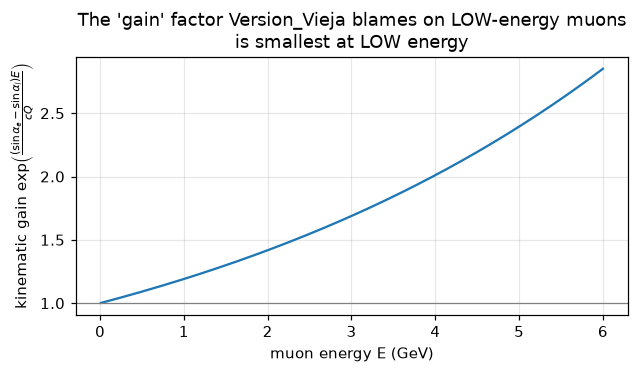

In [5]:
Es = np.linspace(0.01, 6, 200)
kin_gain = np.exp((np.sin(ae) - np.sin(al)) * Es / 0.20)
plt.figure(figsize=(6, 3.5))
plt.plot(Es, kin_gain)
plt.axhline(1, color="gray", lw=0.8)
plt.xlabel("muon energy E (GeV)")
plt.ylabel(r"kinematic gain $\exp\!\left(\frac{(\sin\alpha_e-\sin\alpha_l)E}{cQ}\right)$")
plt.title("The 'gain' factor Version_Vieja blames on LOW-energy muons\nis smallest at LOW energy")
plt.tight_layout()
plt.show()

### 2b. Two different "α"s — why a *narrower* muon population discriminates *more*, not less

It's tempting to object: `sinα ≈ p_t/E`, and Cazón's `p_t` distribution is
bounded (characteristic scale `Q`, it never runs away to arbitrarily large
values) — so a *low-energy* muon can clearly reach a *larger* angle than a
high-energy one for the same `p_t`. That's completely correct. But it's a
statement about a different `α` than the one that matters for Eq. (9)'s
early/late comparison, and keeping the two apart is the whole resolution:

- **The muon's own characteristic emission angle**, $\alpha_{typ}(E) \sim
  Q/E$ — genuinely shrinks with $E$, exactly as the bounded-$p_t$ argument
  says.
- **The angle *required* to reach a specific ground point** — $\alpha_{early}$
  and $\alpha_{late}$, fixed the moment $(r,\theta,D)$ are fixed. This is
  pure ballistics (two points in space determine the line between them) and
  does **not** know the muon's energy at all.

The early/late *asymmetry* comes from comparing a population's width to the
**fixed** gap between these two required angles — not from how wide the
population is in isolation. A low-energy population is so wide
($\alpha_{typ}\gg\Delta\alpha$) that it can't tell $\alpha_{early}$ from
$\alpha_{late}$ apart — both sit deep in its bulk, roughly equally likely,
so the exponential factor is $\approx 1$ (no gain) and the energy-independent
spatial term wins by default (early-favouring). A high-energy population is
narrow enough ($\alpha_{typ}\ll\Delta\alpha$) to resolve the two, and being
a *steeply falling* function of angle, it strongly prefers whichever
required angle is *smaller* — which is $\alpha_{late}$. So the gain grows
with $E$ precisely *because* the population narrows with $E$, not despite it.

In [6]:
Delta_alpha = ae - al  # the FIXED geometric gap at the reference point (radians)
print(f"Fixed geometric gap  Delta_alpha = alpha_early - alpha_late = {np.degrees(Delta_alpha):.2f} deg"
      f"  (does not depend on E)")

Q_ref = 0.20
for E in (0.1, 0.3, 1.0, 3.0, 10.0):
    alpha_typ = Q_ref / E  # sin(alpha) ~ p_t/E, characteristic p_t ~ Q -> alpha_typ ~ Q/E (small-angle)
    verdict = "population >> gap: can't resolve early vs. late" if alpha_typ > 3 * Delta_alpha else (
        "population << gap: sharply resolves early vs. late" if alpha_typ < Delta_alpha / 3 else
        "comparable: transition regime")
    print(f"  E={E:5.1f} GeV  ->  alpha_typ ~ Q/E = {np.degrees(alpha_typ):6.2f} deg   ({verdict})")

E_heuristic = Q_ref / Delta_alpha
print(f"\nOrder-of-magnitude crossover from 'population width = geometric gap': "
      f"E ~ Q/Delta_alpha = {E_heuristic:.2f} GeV")
print(f"Exact crossover from the full root-solve (Section 3 below): E* = {crossover_energy(r_ref, D_ref, theta_ref, Q_ref):.2f} GeV")
print("(same ballpark -- the exact value is lower because the exponential also has to")
print(" overcome the ~0.65 spatial-term handicap, not just reach angular parity)")

Fixed geometric gap  Delta_alpha = alpha_early - alpha_late = 2.03 deg  (does not depend on E)
  E=  0.1 GeV  ->  alpha_typ ~ Q/E = 114.59 deg   (population >> gap: can't resolve early vs. late)
  E=  0.3 GeV  ->  alpha_typ ~ Q/E =  38.20 deg   (population >> gap: can't resolve early vs. late)
  E=  1.0 GeV  ->  alpha_typ ~ Q/E =  11.46 deg   (population >> gap: can't resolve early vs. late)
  E=  3.0 GeV  ->  alpha_typ ~ Q/E =   3.82 deg   (comparable: transition regime)
  E= 10.0 GeV  ->  alpha_typ ~ Q/E =   1.15 deg   (comparable: transition regime)

Order-of-magnitude crossover from 'population width = geometric gap': E ~ Q/Delta_alpha = 5.65 GeV
Exact crossover from the full root-solve (Section 3 below): E* = 2.48 GeV
(same ballpark -- the exact value is lower because the exponential also has to
 overcome the ~0.65 spatial-term handicap, not just reach angular parity)


## 3. Where does the ratio actually cross 1? The crossover energy E*

Since the spatial and cosine factors don't depend on `E` at all, and the
exponential factor is monotonically increasing in `E`, the *whole* ratio
`S_late/S_early(E)` is monotonically increasing in `E`. That means there is
exactly **one** crossover energy `E*` where it equals 1 (equal density,
`A1=0`): below `E*` the net effect is early-favouring (positive A1, same
sign as attenuation); above `E*` it's late-favouring (negative A1).

This `E*` is the single most important number in this whole review. If
`E*` sits *above* the UMD's own effective threshold
($E_\mu \gtrsim 1\,\mathrm{GeV}/\cos\theta$), then "Population B" — defined
by both GAP notes as the muons the UMD filters *out*, i.e. exactly the
low-energy population below that threshold — sits entirely on the
early-favouring side of the crossover, the opposite of what the note's
prose needs.

D= 5.0 km  ->  E* = 1.64 GeV
D= 7.5 km  ->  E* = 2.48 GeV
D=10.0 km  ->  E* = 3.32 GeV


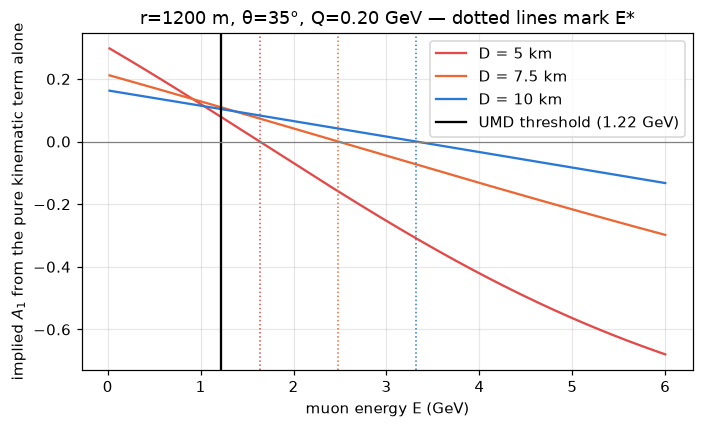

In [7]:
# (crossover_energy was already defined in Section 2b, above)
fig, ax = plt.subplots(figsize=(6.5, 4))
for D_km, color in zip([5, 7.5, 10], ["#e34948", "#eb6834", "#2a78d6"]):
    D = D_km * 1000
    Es = np.linspace(0.02, 6, 300)
    A1s = [A1_from_ratio(ratio(E, r_ref, D, theta_ref, 0.20)) for E in Es]
    ax.plot(Es, A1s, color=color, label=f"D = {D_km} km")
    Estar = crossover_energy(r_ref, D, theta_ref, 0.20)
    ax.axvline(Estar, color=color, ls=":", lw=1)
    print(f"D={D_km:4.1f} km  ->  E* = {Estar:.2f} GeV")

umd_thr = 1.0 / np.cos(np.radians(theta_ref))
ax.axvline(umd_thr, color="k", lw=1.5, label=f"UMD threshold ({umd_thr:.2f} GeV)")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("muon energy E (GeV)")
ax.set_ylabel(r"implied $A_1$ from the pure kinematic term alone")
ax.set_title(f"r={r_ref:.0f} m, θ={theta_ref:.0f}°, Q=0.20 GeV — dotted lines mark E*")
ax.legend()
plt.tight_layout()
plt.show()

**Reading this plot:** for every production height in the 5-10 km range
both cited sources point to, `E*` (where each curve crosses zero) sits at
or above the UMD's own ~1.2 GeV threshold at this angle (black vertical
line). Everything to the *left* of `E*` — which includes essentially all of
"Population B" as either GAP note defines it — is on the **positive**
(early-favouring) side. Population B does not sit in the regime the
narrative needs it to.

This is not a fluke of one radius/angle. The next cell scans production
height `D` directly to ask: *how low would D have to be for E* to actually
drop into Population B's own range?*

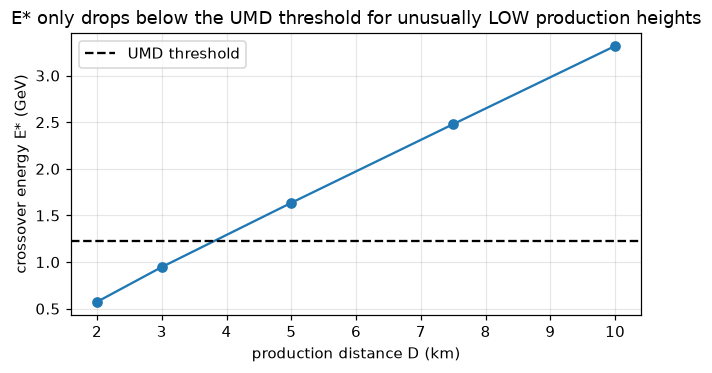

  D=  2.0 km  ->  E* = 0.57 GeV
  D=  3.0 km  ->  E* = 0.95 GeV
  D=  5.0 km  ->  E* = 1.64 GeV
  D=  7.5 km  ->  E* = 2.48 GeV
  D= 10.0 km  ->  E* = 3.32 GeV


In [8]:
Ds_km = np.array([2, 3, 5, 7.5, 10])
Estars = [crossover_energy(r_ref, D * 1000, theta_ref, 0.20) for D in Ds_km]
plt.figure(figsize=(6, 3.5))
plt.plot(Ds_km, Estars, "o-")
plt.axhline(umd_thr, color="k", ls="--", label="UMD threshold")
plt.xlabel("production distance D (km)")
plt.ylabel("crossover energy E* (GeV)")
plt.title("E* only drops below the UMD threshold for unusually LOW production heights")
plt.legend()
plt.tight_layout()
plt.show()
for D, Es_ in zip(Ds_km, Estars):
    print(f"  D={D:5.1f} km  ->  E* = {Es_:.2f} GeV")

The story isn't falsified for *every* geometry — only for the D ≈ 5-10 km
that Cazón's own worked example and Bertou & Billoir's own text point to.
Rescuing it for Population B specifically would require an anti-correlation
between production height and muon energy (unusually low-energy muons born
unusually close to the ground) that neither GAP note invokes or checks.

### 3b. Does that anti-correlation actually exist? Checking Cazón (2012) directly

Everything above treated `D` as one free knob, swept independently of `E`.
That's a real simplification: does the *actual* production height of a muon
correlate with its energy? Cazón (2012) addresses this head-on — their
whole point is that a factorized model $F(X,E,p_t)=h(X)f_X(E,p_t)$ (energy
and $p_t$ distributions independent of depth $X$) is *not* accurate, and
their Fig. 4 (right panel) plots exactly the correlation needed here: the
median/average muon energy at production as a function of
$X'=X-X^\mu_{max}$ (depth relative to the muon-production maximum; $X'<0$
is *before* the maximum — higher up, larger $D$; $X'>0$ is *after* it —
deeper, smaller $D$, closer to ground). Read off that figure: the median
energy is a few GeV at $X'\approx-500\,\mathrm{g/cm^2}$ and drops to well
under 1 GeV by $X'\approx+1000\,\mathrm{g/cm^2}$.

**This says higher-energy muons are produced preferentially *before* the
shower maximum (farther from the ground, larger D), and lower-energy muons
preferentially *after* it (closer to the ground, smaller D)** — a real
correlation, but the **opposite direction** from "high energy → closer to
the ground." It matches the general EAS picture: energetic secondaries
either interact again (extending the cascade) or, if they do decay
promptly, tend to do so earlier, while the enormous low-energy multiplicity
builds up progressively deeper, around and after the cascade's maximum.

**Why this matters for E\*, and which way it cuts:** the fixed geometric
gap $\Delta\alpha = \alpha_{early}-\alpha_{late}$ is not just a number that
happens to be small at D=7.5 km — it shrinks *fast* as D grows (an exact
geometric fact, nothing approximate about it):

In [9]:
print(f"{'D (km)':>8} {'Delta_alpha (deg)':>20} {'spatial factor':>16}")
for D_km in (2, 3, 5, 7.5, 10, 15, 20):
    _, _, ae_, al_, _, _, sp_, cf_ = factors(r_ref, D_km * 1000, theta_ref)
    print(f"{D_km:8.1f} {np.degrees(ae_ - al_):20.3f} {sp_:16.3f}")

  D (km)    Delta_alpha (deg)   spatial factor
     2.0               23.073            0.293
     3.0               11.704            0.377
     5.0                4.481            0.527
     7.5                2.027            0.645
    10.0                1.147            0.717
    15.0                0.512            0.800
    20.0                0.288            0.846


So the two robust facts point the *same* way, and it's against the
narrative, not for it: the muon population energetic enough to sit above
`E*` (where the exponential gain would actually matter) is, per Cazón's own
Fig. 4, also the population found preferentially at *larger* D — exactly
where the geometric gap it would need to discriminate has *already shrunk
to under a degree*. A population needs both a narrow enough angular spread
(favoured by high E) **and** a wide-enough gap to resolve (favoured by
small D) to produce a strong late-favouring gain — and Cazón's own
correlation ties high E to *exactly* the D range where that gap is
smallest. Accounting for the real E-D correlation makes the late-favouring
mechanism *harder* to sustain than the already-conservative fixed-D
treatment above, not easier.

**What this section deliberately does not do:** turn this into one clean
corrected E\* number. That needs digitising Cazón's Fig. 4 properly (it was
produced for $10^{19}$ eV, $60°$ showers, not the $10^{17.5-18}$ eV,
$30$-$40°$ regime either GAP note actually uses) and pinning down
$X^\mu_{max}$ for *that* regime specifically. A first attempt at chaining a
rough eyeballed fit of Fig. 4 through the same isothermal-atmosphere
conversion used in Section 9 broke down outside a narrow calibration range
(it produced unphysical negative production distances at low E) —
instructive as a sign that this needs real digitized data or, better, a
direct read of the per-muon $(E, X)$ pairs already sitting in the group's
own CORSIKA output, not another hand-fit exponential. That's now added to
`discriminating_analysis_proposal.md`'s check list.

## 4. Independent cross-check: this is the same mechanism Luce et al. (2021) already published

Luce, Roth, Schmidt & Veberič (ICRC 2021, #435) — cited by both GAP notes,
but only for the *observation* that the SD inverts, never engaged with as a
model — already derive a structurally identical result in their §2.2. They
model the geometric solid-angle dilution the same way ($\Delta\Omega \propto
1/d^2$) and an Angular Distribution Function $\mathrm{ADF}(\delta) \propto
(\delta/\delta_0)^{-\gamma}$ (a *power law* in the emission angle, rather
than Cazón's exponential), and state (their text, verbatim):

> "at large distances, the value of the exponent γ of the ADF can be large
> enough to compensate the attenuation and produce a negative amplitude of
> the asymmetry."

with an asymmetry amplitude $\alpha \propto 2 - \gamma + d(\theta)/\lambda$.
Term for term: `+2` is their version of the spatial $1/d^2$ factor,
`-γ` is their version of the angular/kinematic gain, `+d/\lambda` is
ordinary atmospheric attenuation (which Eq. (9) omits entirely — see the
caveat at the end of this notebook). **Nothing here is inverted relative to
Version_Vieja's Eq. (9)** — both agree completely on which physical
ingredient pushes which way. What Luce's own text confirms independently is
the *conditional* nature of the late-favouring term: it only wins "at large
distances" (i.e. once γ, or equivalently E, is large), exactly matching the
E* result above.

The bridge between the two languages: an exponential $e^{-k\alpha}$ behaves,
*locally* at some angle α, like a power law with effective index
$\gamma_{eff} = k\alpha$ (match the logarithmic slopes:
$d\ln f/d\ln\alpha = -k\alpha$ for the exponential, $=-\gamma$ for the power
law). Here $k = E/(cQ)$, so:

$$\gamma_{eff} = \frac{E\,\bar\alpha}{cQ}$$

In [10]:
def luce_gamma_eff(E, r, D, theta_deg, Q):
    """Local power-law index that Cazon's exponential ADF mimics at the mean
    of the early/late emission angles -- i.e. Luce's own gamma, evaluated
    for Cazon's exponential model instead of a literal power law."""
    _, _, ae, al, *_ = factors(r, D, theta_deg)
    alpha_mean = 0.5 * (ae + al)
    gamma_eff = E * alpha_mean / Q
    return 2.0 - gamma_eff  # pure geometric+kinematic part of Luce's alpha, attenuation term dropped to isolate it


for E in (0.3, 1.0, 1.22, 2.48, 3.0, 5.0):
    g = luce_gamma_eff(E, r_ref, D_ref, theta_ref, 0.20)
    tag = "early-favouring" if g > 0 else "late-favouring"
    print(f"  E={E:5.2f} GeV  ->  2 - gamma_eff = {g:+.3f}  ({tag})")

  E= 0.30 GeV  ->  2 - gamma_eff = +1.759  (early-favouring)
  E= 1.00 GeV  ->  2 - gamma_eff = +1.197  (early-favouring)
  E= 1.22 GeV  ->  2 - gamma_eff = +1.020  (early-favouring)
  E= 2.48 GeV  ->  2 - gamma_eff = +0.009  (early-favouring)
  E= 3.00 GeV  ->  2 - gamma_eff = -0.409  (late-favouring)
  E= 5.00 GeV  ->  2 - gamma_eff = -2.015  (late-favouring)


The sign flips at essentially the same E* found in Section 3 — an
independent confirmation, via a differently-parametrized model from an
already-refereed proceedings paper, that the late-favouring gain needs
*high* energy (or, in Luce's language, a *large* effective γ, which only
large distances/angles supply), not low energy.

**A caveat worth stating plainly:** Luce's own paper does not spell out the
derivation behind $\alpha \propto 2-\gamma+d/\lambda$ (it defers to their
Ref. [6]), so the correspondence above is a physically-motivated mapping of
three shared ingredients (geometric dilution, angular/kinematic gain,
attenuation) onto Cazón's exponential model — not a term-by-term algebraic
identity checked against Luce's own unpublished-here derivation.

## 5. Does the WCD tank's 3D shape rescue the "late excess" story? — the Cauchy/Cavalieri identity

GAP-2026-041's own replacement mechanism (§6, after Eq. 9's derivation was
cut) is different: it says the WCD tank's *volume* — top surface plus
cylindrical side wall, unlike the UMD's flat scintillator plane — biases
the *reconstructed* signal (VEM, i.e. deposited energy, not raw particle
count) toward the late region, because grazing (late-region) muons cross
more water and deposit more energy per particle.

**That per-particle claim is completely correct and not in dispute.** The
missing piece is what happens to the *number* of particles that enter at
that grazing angle in the first place.

### The exact geometric identity

Picture a tank as a solid of volume $V$, illuminated by a beam of muons all
travelling in one fixed direction (fixed local incidence angle
$\theta_{loc}$). Two quantities:

- **How many muons hit the tank per unit time**, $N$, is proportional to
  the *projected area* the tank presents to that beam direction,
  $A_\perp(\theta_{loc})$ — the "shadow" of the tank as seen head-on from
  the beam. A more grazing (larger $\theta_{loc}$) beam sees a *smaller*
  projected area from the top, but the side wall's projected area grows —
  this is exactly the top/side trade-off Bertou & Billoir's own $A_{side}$
  formula describes (their GAP-2000-017, §6).
- **How much water each of those muons crosses**, i.e. the chord length,
  varies from muon to muon depending on exactly where it enters — but the
  **average** chord length over the whole illuminated cross-section has an
  exact value: slice the tank into thin layers along the beam direction
  (Cavalieri's principle — literally just adding up all the chords, each
  one contributing to the volume it passes through), and the *total* path
  length summed over every muon that crosses the tank equals exactly the
  tank's volume $V$, **for any incidence angle**, because every chord
  contributes to filling up the same fixed volume regardless of the angle
  it's sliced at. So mean chord length = $V / A_\perp(\theta_{loc})$.

Multiplying number of muons by mean chord length per muon gives the
**total** path length crossed by the whole beam — i.e. the quantity the
VEM signal (energy deposit ∝ path length in water, for muons well above
minimum-ionizing) is actually proportional to:

$$N \times \bar\ell = F_\perp \cdot A_\perp(\theta_{loc}) \times \frac{V}{A_\perp(\theta_{loc})} = F_\perp \cdot V$$

The projected-area term **cancels exactly**, at *every* incidence angle.
The muon VEM signal per unit incident flux does not depend on incidence
angle at all — not "is suppressed", genuinely **zero** dependence, for an
idealized single-direction beam. (This exact fixed-direction identity is a
direct consequence of Cavalieri's slicing principle. It is closely related
to — but a more elementary special case of — the integral-geometry result
usually called "Cauchy's mean-chord formula", which states the *same*
thing after also averaging over *all* incidence directions; the earlier
notes in this folder used the name "Cauchy" a little loosely for what is,
at fixed angle, really just Cavalieri's principle. The math is identical
either way and the conclusion doesn't change.)

This is exactly what Bertou & Billoir themselves say, in words, without
giving it a name (GAP-2000-017, §6, verbatim): *"the signal of a muon is
roughly proportional to the length of water crossed... the side signal per
muon will be much stronger than the top one (the factor 2.4 being
reversed). This compensates the surface factor, and we expect the 'early'
muonic signal to be the same as the 'late' one."* Their own Fig. 6 MC check
shows the total late/early signal ratio flattening around 0.78-0.83 (i.e.
$A_1\approx+0.11$ to $+0.13$) out to 2.4 km — **it never crosses zero.**
**B&B did think this through, correctly — GAP-2026-041's own attribution of
a *negative* contribution to them is what doesn't survive a check against
their own conclusion.**

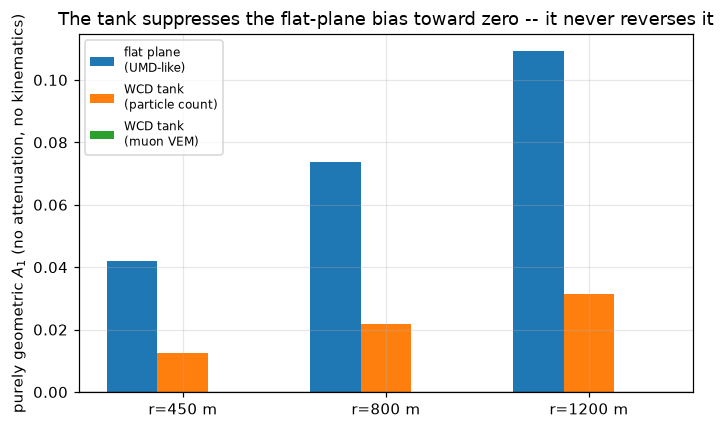

[[0.04186149 0.01262116 0.        ]
 [0.07384396 0.02191786 0.        ]
 [0.10920298 0.03145555 0.        ]]


In [11]:
R_TANK, H_TANK = 1.8, 1.2  # Auger WCD radius/height (m) -- top/side area ratio ~2.36, matching B&B's quoted 2.4


def tank_response(r, D, theta_deg):
    """A1 of a detector's purely geometric response, three ways:
      - flat horizontal plane (UMD-like): count ~ cos(theta_loc)
      - WCD tank, raw particle count: count ~ projected aperture (top+side)
      - WCD tank, muon VEM (energy-weighted): angle-independent by the
        identity above, so A1 = 0 EXACTLY, not "approximately small"."""
    _, _, _, _, tle, tll, _, _ = factors(r, D, theta_deg)

    flat_e, flat_l = np.cos(tle), np.cos(tll)
    A1_flat = A1_from_ratio(flat_l / flat_e)

    Atop, Aside_proj = np.pi * R_TANK ** 2, 2 * R_TANK * H_TANK
    count_e = Atop * np.cos(tle) + Aside_proj * np.sin(tle)
    count_l = Atop * np.cos(tll) + Aside_proj * np.sin(tll)
    A1_count = A1_from_ratio(count_l / count_e)

    A1_VEM = 0.0  # exact, by the Cavalieri/Cauchy identity above
    return A1_flat, A1_count, A1_VEM


radii = [450.0, 800.0, 1200.0]
labels = ["flat plane\n(UMD-like)", "WCD tank\n(particle count)", "WCD tank\n(muon VEM)"]
x = np.arange(len(radii))
width = 0.25
fig, ax = plt.subplots(figsize=(6.5, 4))
vals = np.array([tank_response(r_, D_ref, theta_ref) for r_ in radii])  # shape (3 radii, 3 responses)
for i, lab in enumerate(labels):
    ax.bar(x + (i - 1) * width, vals[:, i], width, label=lab)
ax.set_xticks(x)
ax.set_xticklabels([f"r={r_:.0f} m" for r_ in radii])
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel(r"purely geometric $A_1$ (no attenuation, no kinematics)")
ax.set_title("The tank suppresses the flat-plane bias toward zero -- it never reverses it")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(vals)

**This directly answers the "why doesn't the per-particle grazing-angle
intuition win?" question.** It's not wrong — it's incomplete on its own.
Each grazing (late-region) muon really does deposit more energy. But
correspondingly *fewer* muons arrive at that grazing angle in the first
place (smaller projected aperture at a more extreme angle) — and those two
effects cancel *exactly* when you sum over the whole beam, by the identity
above. The bar chart shows this numerically: the raw **count** bias is
still positive (early-favouring, +0.03, a residual "headwind" against the
late-region excess needed) even after including the enhanced side-wall
entries in the late region; and the **VEM** bias — the one that folds in
the enhanced per-particle deposit — is exactly zero, confirming the tank's
volume doesn't just shrink the flat-plane bias, it erases it completely for
the energy-weighted channel.

## 6. The UMD's own unaccounted-for instrumental asymmetries

Neither GAP note subtracts two purely geometric, purely positive
(early-favouring) contributions that a flat, buried, particle-**counting**
detector like the UMD retains in full — precisely *because* it has no
volume to provide the Section 5 cancellation.

**1. Flat-plane aperture** — this is nothing but $A_{geo}$ itself (Bertou &
Billoir's own term, which both GAP notes correctly call "strictly
positive"), evaluated for the UMD's own horizontal plane instead of an
idealized ground plane. It is *not* a term the GAP notes deny applies to
the UMD (see the discussion of this in the main reply, point D) — it's
simply never separately quantified there.

**2. Azimuthally-modulated overburden threshold** — both GAP notes write
the UMD's threshold as $E_\mu\gtrsim1\,\mathrm{GeV}/\cos\theta$, using the
*global* shower zenith angle θ. But the angle that actually sets how much
soil a muon has to punch through is the **local** incidence angle at the
module, $\theta_{loc}$ — and Section 1's printout already showed
$\theta_{loc}$ is larger in the late region than the early region, for
exactly the same geometric reason the tank's side wall is more exposed
there. A larger local angle means a *higher* effective threshold in the
late region, which removes relatively more low-energy muons there — a
purely instrumental, purely positive (early-favouring) contribution to
$A_1$ that has nothing to do with atmospheric attenuation.

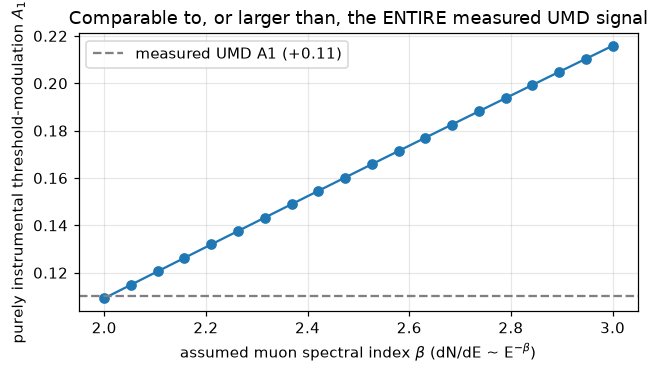

Flat-plane A_geo-type term at the reference point: A1 = +0.109
  beta=2.0: E_thr(early)=1.10 GeV, E_thr(late)=1.37 GeV  ->  A1_threshold = +0.109
  beta=2.6: E_thr(early)=1.10 GeV, E_thr(late)=1.37 GeV  ->  A1_threshold = +0.174
  beta=3.0: E_thr(early)=1.10 GeV, E_thr(late)=1.37 GeV  ->  A1_threshold = +0.216


In [12]:
def umd_threshold_A1(r, D, theta_deg, beta):
    """Purely instrumental A1 from E_thr(theta_loc) = 1 GeV / cos(theta_loc),
    assuming a power-law muon flux dN/dE ~ E^-beta near threshold so that
    the surviving fraction above E_thr scales as E_thr^-(beta-1)."""
    _, _, _, _, tle, tll, _, _ = factors(r, D, theta_deg)
    Ethr_e, Ethr_l = 1.0 / np.cos(tle), 1.0 / np.cos(tll)
    Nsurv_e, Nsurv_l = Ethr_e ** -(beta - 1), Ethr_l ** -(beta - 1)
    return A1_from_ratio(Nsurv_l / Nsurv_e), Ethr_e, Ethr_l


betas = np.linspace(2.0, 3.0, 20)
A1s_thr = [umd_threshold_A1(r_ref, D_ref, theta_ref, b)[0] for b in betas]
plt.figure(figsize=(6, 3.5))
plt.plot(betas, A1s_thr, "o-")
plt.axhline(0.11, color="gray", ls="--", label="measured UMD A1 (+0.11)")
plt.xlabel(r"assumed muon spectral index $\beta$ (dN/dE ~ E$^{-\beta}$)")
plt.ylabel(r"purely instrumental threshold-modulation $A_1$")
plt.title("Comparable to, or larger than, the ENTIRE measured UMD signal")
plt.legend()
plt.tight_layout()
plt.show()
A1_flat_umd = A1_from_ratio(np.cos(tll) / np.cos(tle))
print(f"Flat-plane A_geo-type term at the reference point: A1 = {A1_flat_umd:+.3f}")
for b in (2.0, 2.6, 3.0):
    a1, Ee, El = umd_threshold_A1(r_ref, D_ref, theta_ref, b)
    print(f"  beta={b:.1f}: E_thr(early)={Ee:.2f} GeV, E_thr(late)={El:.2f} GeV  ->  A1_threshold = {a1:+.3f}")

Both terms, individually, are the same order of magnitude as the entire
measured UMD signal (+0.11 at this point). These are order-of-magnitude,
single-production-point estimates, not corrections to plug directly into
the thesis or the GAP note — but they're large enough that "the UMD's A1 is
purely attenuation-driven" is not something either note actually
establishes; the note simply never separates attenuation from the
always-present $A_{geo}$-type geometric term, nor the always-present
threshold-modulation term.

## 7. Backing out the true incident-flux asymmetry from the reported MC-truth count

Because the tank's own geometric term cancels *exactly* for the VEM signal
(Section 5) — not just "on average for a uniform flux", but region by
region, for whatever the true flux happens to be doing in that region — the
muon VEM signal is a clean, undistorted tracer of the true incident muon
flux ratio. That means the reported raw MC-truth **count** asymmetry (which
*does* retain the tank's mild aperture-only bias, since counting doesn't
benefit from the chord-length cancellation) can be corrected for that known
instrumental bias to estimate what the true flux ratio must be:

$$\text{count ratio} = \text{true flux ratio} \times \text{aperture ratio}
\quad\Rightarrow\quad
\text{true flux ratio} = \frac{\text{count ratio (reported)}}{\text{aperture ratio (computed)}}$$

In [13]:
def implied_true_flux_A1(r, D, theta_deg, reported_count_A1):
    A1_flat, A1_count, A1_VEM = tank_response(r, D, theta_deg)
    ratio_count_reported = (1 - reported_count_A1) / (1 + reported_count_A1)
    ratio_aperture = (1 - A1_count) / (1 + A1_count)
    ratio_flux = ratio_count_reported / ratio_aperture
    return A1_from_ratio(ratio_flux), A1_count


A1_flux, A1_count_only = implied_true_flux_A1(r_ref, D_ref, theta_ref, reported_count_A1=-0.10)
print(f"Tank-count-only aperture bias      = {A1_count_only:+.3f}  (early-favouring, masks part of the true signal)")
print(f"Reported SD-Muon(MC) count A1      = -0.100  (Table 2, both GAP notes)")
print(f"Implied TRUE incident-flux A1      = {A1_flux:+.3f}")

Tank-count-only aperture bias      = +0.031  (early-favouring, masks part of the true signal)
Reported SD-Muon(MC) count A1      = -0.100  (Table 2, both GAP notes)
Implied TRUE incident-flux A1      = -0.131


The true flux has to be **more** inverted (~-0.13) than the reported raw
count (-0.10), because the tank's own early-favouring aperture bias was
partially masking it. This produces a **falsifiable, zero-new-simulation
prediction**: if a muon-only VEM/energy-deposit variable is isolated at
MC-truth level (not currently broken out in either GAP note — only total
VEM and muon *count* are shown), it should show a *larger* inversion than
the muon count, not a smaller one.

**Caveat:** this assumes every muon in a given azimuthal region arrives
along one single nominal direction (the geometric $\theta_{loc}$ computed
above), not a spread of directions. Real muons have their own angular
spread (the kinematic-divergence effect itself) around that nominal
direction, so this is a first-order correction, not an exact
deconvolution.

## 8. Does kinematic divergence survive being averaged over a real muon spectrum?

Section 3 evaluated the ratio at *one* fixed muon energy at a time. Real
muon populations are not monochromatic — they follow something close to a
power-law spectrum $dN/dE \propto E^{-\gamma}$ (Cazón quotes $\gamma\approx
2.6$ near production). The natural next question: does the **net**,
properly-averaged effect over that whole realistic mixture actually favour
late, once you account for the fact that only a rare, exponentially
shrinking tail of muons sits above $E^*$?

$$\left\langle \rho(E) \right\rangle
= \frac{\int_{E_{min}}^{E_{max}} E^{-\gamma}\,\rho(E)\,dE}{\int_{E_{min}}^{E_{max}} E^{-\gamma}\,dE}$$

where $\rho(E)$ is exactly the `ratio(E, ...)` function from Section 3, and
the weighting `E^-γ` says "there are many more low-energy muons than
high-energy ones, weight the average accordingly."

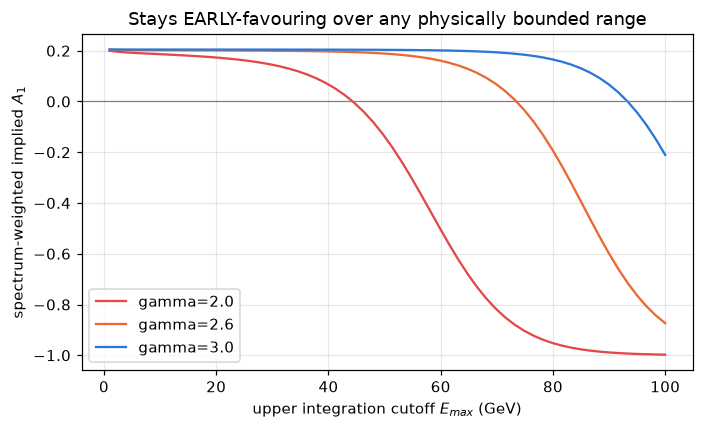

Asymptotic growth rate k = 0.1746 /GeV  (ratio(E) ~ exp(k E) at large E,
beats ANY power-law spectrum eventually -- the flip seen far to the right
of the plot above is this toy model's unbounded exponential finally winning
against an unphysically extended power law, not a real physical prediction.)


In [14]:
def spectrum_weighted_kinematic_A1(r, D, theta_deg, Q, gamma, E_min, E_max):
    num = quad(lambda E: E ** (-gamma) * ratio(E, r, D, theta_deg, Q), E_min, E_max, limit=200)[0]
    den = quad(lambda E: E ** (-gamma), E_min, E_max, limit=200)[0]
    rho_avg = num / den
    return A1_from_ratio(rho_avg), rho_avg


fig, ax = plt.subplots(figsize=(6.5, 4))
Emaxs = np.linspace(1, 100, 60)
for gamma, color in zip([2.0, 2.6, 3.0], ["#e34948", "#eb6834", "#2a78d6"]):
    A1s = [spectrum_weighted_kinematic_A1(r_ref, D_ref, theta_ref, 0.20, gamma, 0.05, Emax)[0] for Emax in Emaxs]
    ax.plot(Emaxs, A1s, color=color, label=f"gamma={gamma}")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"upper integration cutoff $E_{max}$ (GeV)")
ax.set_ylabel(r"spectrum-weighted implied $A_1$")
ax.set_title("Stays EARLY-favouring over any physically bounded range")
ax.legend()
plt.tight_layout()
plt.show()

k = (np.sin(ae) - np.sin(al)) / 0.20
print(f"Asymptotic growth rate k = {k:.4f} /GeV  (ratio(E) ~ exp(k E) at large E,")
print("beats ANY power-law spectrum eventually -- the flip seen far to the right")
print("of the plot above is this toy model's unbounded exponential finally winning")
print("against an unphysically extended power law, not a real physical prediction.)")

**Reading this plot:** over any energy range a real muon spectrum actually
populates (up to ~20 GeV, generously), the spectrum-weighted term stays
**early-favouring** for every spectral index tried. It only crosses zero
once the integral is extended to tens-to-hundreds of GeV — energies no
physically-motivated ground-level muon spectrum at these radii/primary
energies has appreciable flux at, and only because the toy exponential ADF
grows without bound ($\rho(E)\sim e^{kE}$), which necessarily beats *any*
power-law falloff eventually. That crossover is the toy model being
extrapolated outside where it was calibrated, not a discovery.

**This retracts a hypothesis worth naming honestly**: that a rare
high-energy tail above $E^*$ might dominate a properly-weighted average and
explain the SD's inversion after all. Checked directly, it doesn't survive.
Kinematic divergence — evaluated at a single energy (Section 3) or
averaged over a realistic spectrum (this section) — does not produce a
net late-favouring effect for the true muon flux, only for individual
high-energy muons considered in isolation, of which there are too few to
matter.

## 9. A candidate with the right sign, quantified honestly: in-flight atmospheric scattering

Every mechanism checked so far (Sections 1-8) assumes muons fly in a
perfectly straight line from their production point to the ground — the
*only* angular spread considered is the one imparted at birth (the
transverse-momentum kick modelled by Cazón). But muons are charged
particles crossing several km of atmosphere, and every charged particle
passing through matter gets randomly nudged, many times, by the Coulomb
field of the nuclei it passes near — "multiple Coulomb scattering". This is
a *second*, independent source of angular spread, additive to the
production-kinematics one, and it grows with how much atmosphere (slant
depth) the muon has crossed.

Since late-region muons cross **more** slant depth than early-region ones
(Section 1's `theta_loc` already hints at why: they arrive more obliquely,
but the direct driver here is that the production-to-ground path length
is genuinely longer), they should pick up **more** in-flight scattering —
smearing their arrival directions more than early-region muons'. This has
the qualitatively *right* sign to help produce a late-region excess: more
smearing effectively "leaks" a bit more of the steep exponential
angular distribution toward whatever narrow angle a given ground point
demands, boosting the late/early ratio a little further beyond what pure
production kinematics alone predicts.

The standard estimate for the RMS scattering angle after crossing depth
`X` (radiation lengths $X/X_0$) is the Highland formula:

$$\theta_0 = \frac{0.0136\,\mathrm{GeV}}{\beta p}\sqrt{X/X_0}\left(1+0.038\ln(X/X_0)\right)$$

Slant depth traversed: early=568 g/cm2, late=708 g/cm2, ratio=1.245


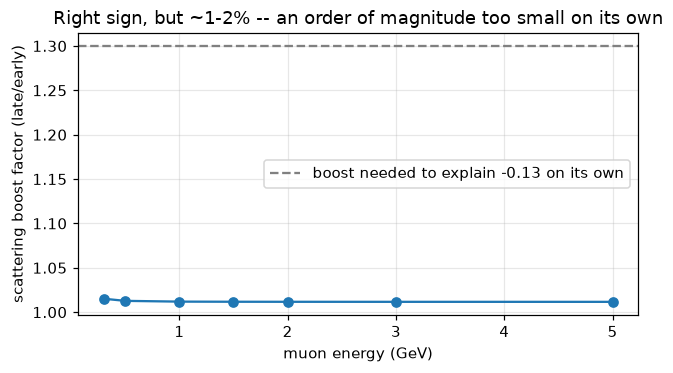

  E= 0.3 GeV  ->  boost = 1.0152
  E= 0.5 GeV  ->  boost = 1.0127
  E= 1.0 GeV  ->  boost = 1.0119
  E= 1.5 GeV  ->  boost = 1.0117
  E= 2.0 GeV  ->  boost = 1.0117
  E= 3.0 GeV  ->  boost = 1.0117
  E= 5.0 GeV  ->  boost = 1.0116


In [15]:
X0_AIR = 36.62  # g/cm^2, radiation length of air
M_MU = 0.10566  # GeV, muon rest mass


def slant_depth(theta_loc_rad, D, theta_deg, X_ground=880.0, alt_ground_km=1.4, H=7.25, X0_sea=1030.0):
    """Vertical atmospheric depth from production altitude to ground
    (isothermal exponential atmosphere, scale height H), converted to slant
    depth along the actual local arrival direction."""
    D_km = D / 1000.0
    alt_prod_km = alt_ground_km + D_km * np.cos(np.radians(theta_deg))
    X_prod = X0_sea * np.exp(-alt_prod_km / H)
    vertical_depth = X_ground - X_prod
    return vertical_depth / np.cos(theta_loc_rad)


def highland_theta0(E_GeV, X_gcm2, X0=X0_AIR):
    p = np.sqrt(max(E_GeV ** 2 - M_MU ** 2, 1e-9))
    beta = p / E_GeV
    t = X_gcm2 / X0
    return (0.0136 / (beta * p)) * np.sqrt(t) * (1 + 0.038 * np.log(t))  # radians


X_e = slant_depth(tle, D_ref, theta_ref)
X_l = slant_depth(tll, D_ref, theta_ref)
print(f"Slant depth traversed: early={X_e:.0f} g/cm2, late={X_l:.0f} g/cm2, ratio={X_l/X_e:.3f}")


def scattering_boost_factor(E_GeV, r, D, theta_deg, Q):
    """Multiplicative boost to the late/early ratio from the DIFFERENCE in
    in-flight scattering width between regions, via an exponential-tilt
    argument on Cazon's locally-exponential angular distribution:
    boost = exp(k^2 (sigma_late^2 - sigma_early^2) / 2), k = E/Q."""
    _, _, ae, al, tle, tll, _, _ = factors(r, D, theta_deg)
    Xe, Xl = slant_depth(tle, D, theta_deg), slant_depth(tll, D, theta_deg)
    se, sl = highland_theta0(E_GeV, Xe), highland_theta0(E_GeV, Xl)
    k = E_GeV / Q
    return np.exp(k ** 2 * (sl ** 2 - se ** 2) / 2), se, sl


Egrid = np.array([0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0])
boosts = [scattering_boost_factor(E, r_ref, D_ref, theta_ref, 0.20)[0] for E in Egrid]
plt.figure(figsize=(6, 3.5))
plt.plot(Egrid, boosts, "o-")
plt.axhline(1.30, color="gray", ls="--", label="boost needed to explain -0.13 on its own")
plt.xlabel("muon energy (GeV)")
plt.ylabel("scattering boost factor (late/early)")
plt.title("Right sign, but ~1-2% -- an order of magnitude too small on its own")
plt.legend()
plt.tight_layout()
plt.show()
for E, b in zip(Egrid, boosts):
    print(f"  E={E:4.1f} GeV  ->  boost = {b:.4f}")

**Where this leaves things:** the boost is real, has the right sign, and is
derived from bibliography (Grieder 2010, §3.1) not previously cited by
either GAP note or the thesis — but quantified with the standard
Gaussian-core (Highland RMS) approximation, it's only ~1-2%, roughly an
order of magnitude too small to turn Section 8's early-favouring
spectrum-weighted prediction into the implied ~-0.13 true-flux inversion on
its own. It is **not discarded**, because the Highland formula only
describes the Gaussian *core* of the Molière scattering distribution;
Grieder's own text distinguishes this from a separate, rarer "wide-angle"
tail of large single scatters that this estimate cannot capture — and this
whole investigation has already found once (Section 8) that a naive
bulk/RMS estimate can miss a real tail-driven contribution. The direct,
cheap way to settle this is empirical, not a fourth analytic toy model:
compare each simulated muon's actual ground-arrival direction to what
Cazón's production-kinematics-only formula predicts for that same muon —
the gap between the two *is* the propagation-scattering contribution,
measured rather than modelled.

## 10a. A different axis entirely: why does the UMD's A1 *increase* with primary energy? (thesis Ch. 5)

Everything above varies the energy of an *individual muon* at *fixed*
production geometry (D held constant) — that's the axis that decides the
early/late competition for a single muon population within one shower.
The thesis's own Ch. 5 (`05_anillo_denso.tex`, §5.3) asks a completely
different question: across an ensemble of *whole showers* spanning half a
decade in **primary** energy, why does the UMD's $A_1$ increase, while the
SD's *decreases*, as $X_{max}$ deepens? The thesis calls this "a
fundamental physical discrepancy" and gives the right mechanistic split:
the SD is EM-dominated, so its asymmetry tracks the *gradient*
$\partial\rho_{EM}/\partial X$, which flattens (→0) as the observation
point approaches $X_{max}$ — killing the SD's asymmetry as showers get
deeper. The UMD, being purely muonic, instead follows the same finite-$D$
geometric dilution as Eq. (9)'s **spatial** term (Section 2), linearized in
the thesis as $A_\mu \approx 2r\sin\theta/D$ — and since a deeper
$X_{max}$ means a *smaller* $D$ (production point closer to ground), this
term *grows*, not shrinks. This is the *same* D-dependence already plotted
in Section 3b's $\Delta\alpha(D)$ table, just applied along the
primary-energy axis instead of the individual-muon-energy axis. The two
don't conflict — they're independent knobs on the same underlying geometry.

The thesis (§5.3) flags this explicitly as "an interpretive hypothesis...
laying the groundwork for future studies" — i.e. plausible, but not yet
checked quantitatively. It's cheap to check with what's already in this
notebook: take the standard elongation rate
($d X_{max}/d\log_{10}E \approx 55$–$60\,\mathrm{g/cm^2}$/decade), convert
it into a $\Delta D$ over the analysed half-decade of energy via the same
atmosphere model from Section 9, and see whether the resulting shift in the
geometric asymmetry matches the reported $\Delta A_1\approx+0.015$.

In [16]:
r_ch5, theta_ch5 = 450.0, 50.0  # Dense Ring radius; midpoint of Ch.5's 40-60 deg band
th_ch5 = np.radians(theta_ch5)
D_ch5_km = 7.5

def X_axis(D_km, theta_deg):
    thr = np.radians(theta_deg)
    alt = 1.4 + D_km * np.cos(thr)  # alt_ground=1.4 km, same as Section 9
    return (1030.0 * np.exp(-alt / 7.25)) / np.cos(thr)  # X0_sea=1030, H=7.25

X_ref_ch5 = X_axis(D_ch5_km, theta_ch5)
dXdD = -X_ref_ch5 * np.cos(th_ch5) / 7.25  # analytic derivative of X_axis w.r.t. D
dDdX = 1.0 / dXdD

print(f"{'elong. rate':>12} {'Delta_Xmax':>12} {'Delta_D (m)':>12} {'ΔA1 (linearized, thesis Eq.)':>30} {'ΔA1 (exact geometry)':>22}")
for rate in (55.0, 60.0):
    dXmax = rate * 0.5  # half a decade, 17.5 -> 18.0
    dD_km = dDdX * dXmax
    D_new_km = D_ch5_km + dD_km

    # thesis's own linearized formula, A_mu = 2 r sin(theta) / D
    Amu_old = 2 * r_ch5 * np.sin(th_ch5) / (D_ch5_km * 1000)
    Amu_new = 2 * r_ch5 * np.sin(th_ch5) / (D_new_km * 1000)

    # exact geometry, spatial term only (same physics, no small-D approximation)
    _, _, _, _, _, _, sp_old, _ = factors(r_ch5, D_ch5_km * 1000, theta_ch5)
    _, _, _, _, _, _, sp_new, _ = factors(r_ch5, D_new_km * 1000, theta_ch5)
    A1_old, A1_new = A1_from_ratio(sp_old), A1_from_ratio(sp_new)

    print(f"{rate:12.0f} {dXmax:12.1f} {dD_km*1000:12.1f} "
          f"{Amu_new-Amu_old:+30.5f} {A1_new-A1_old:+22.5f}")

print("\nReported empirical Delta_A1 over this same energy window (thesis Fig. 'a1_vs_energia'): +0.015")

 elong. rate   Delta_Xmax  Delta_D (m)   ΔA1 (linearized, thesis Eq.)   ΔA1 (exact geometry)
          55         27.5       -456.5                       +0.00596               +0.00902
          60         30.0       -498.0                       +0.00654               +0.00989

Reported empirical Delta_A1 over this same energy window (thesis Fig. 'a1_vs_energia'): +0.015


**Right sign, right order of magnitude** — both the thesis's own
linearized formula and the exact geometry predict an increase of roughly
half to two-thirds of the reported +0.015, using nothing but a textbook
elongation rate and the same atmosphere model already used for the
scattering estimate. That's a real, if partial, quantitative validation:
not proof the mechanism is the *whole* story (the remaining factor of
~1.5-2.5 could come from the muon-specific $X_{max}$ elongation rate
differing from the EM one used here, an additive contribution from the
$\theta_{loc}$-projection term on top of the pure $1/d^2$ dilution, or
$X_{max}$ fluctuations smearing the reconstructed-energy bins), but enough
to promote this from "interpretive hypothesis" toward "quantitatively
supported, pending the residual gap" — worth stating explicitly in the
thesis text rather than left as an unchecked aside.

## 10. Summary: what this toy-model simulator does and doesn't establish

| Candidate mechanism | Section | Result |
|---|---|---|
| Kinematic divergence, Population B attribution | 3 | Wrong population — early-favouring below E* |
| Kinematic divergence, spectrum-weighted | 8 | Still early-favouring over any physically bounded range |
| Tank/track-length (GAP-2026-041 §6) | 5 | Contributes exactly zero to VEM, not negative |
| Tank aperture on raw count | 5 | Early-favouring (+0.03), not negative |
| In-flight atmospheric scattering | 9 | Right sign, ~1-2% — an order of magnitude short on its own |
| UMD A1 increasing with primary energy (Ch. 5 hypothesis) | 10a | Right sign, ~40-65% of the reported magnitude |

**None of the analytically-tractable mechanisms checked here produces a
late-favouring net effect anywhere near the size the simulation reports
(~-0.13 true-flux, backed out in Section 7).** That is a stronger, more
useful conclusion than either GAP note draws — both assert a specific
mechanism; nothing checked here, using the group's own cited literature's
own formulas, survives being evaluated quantitatively. The true physical
origin of the SD's inferred flux-level inversion remains open, and the next
steps (see `discriminating_analysis_proposal.md` in this folder) point
toward checking this directly against the real per-muon CORSIKA/Offline
simulation output rather than building a fifth analytic toy model.

**What this notebook is not:** a shower simulation. Every number above
comes from an idealized single-production-point, single-slope-Q, one-shot
geometric model. It is useful for exactly one thing — checking whether a
*specific, stated equation* behaves the way a piece of prose claims it
does — and it has done that job for five different claims across
Sections 3, 5, 8, and 9. It cannot replace, and was never meant to
replace, checking the same questions against the real Monte Carlo.